In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import corner


In [229]:
with (np.load("workspaces/higgs/data/photon_pts.npz") as pt_f,
      np.load("workspaces/higgs/data/photon_Es.npz") as E_f,
      np.load("workspaces/higgs/data/photon_etas.npz") as eta_f,
      np.load("workspaces/higgs/data/photon_phis.npz") as phi_f):
    orig_pt = pt_f["data"]
    orig_eta = eta_f["data"]
    orig_phi = phi_f["data"]
    orig_E = E_f["data"]


In [ ]:
with (np.load("workspaces/higgs/higgs_project/output/decompressed_output/decompressed.npz") as f,
      np.load("workspaces/higgs/data/V2_precut_scales.npz") as scalefile):
    decomp_norm = f["data"]
    scales = scalefile["data"]

def norm(arrs):
    norm_arrs = []
    for col in arrs.T:
        mini = np.log10(min(col))
        maxi = np.log10(max(col))
        norm_arrs.append((np.log10(col) - mini)/(maxi - mini))
    return np.column_stack(norm_arrs)

def unnorm(arrs, scales):
    return np.column_stack([10**(col * (scale[1] - scale[0]) + scale[0]) for col, scale in zip(arrs.T, scales)])

decomp_pt = unnorm(decomp_norm[:,0:2], scales[:,0:2])
decomp_eta = unnorm(decomp_norm[:,2:4], scales[:,2:4])
decomp_phi = unnorm(decomp_norm[:,4:6], scales[:,4:6])
decomp_E = unnorm(decomp_norm[:,6:8], scales[:,6:8])



In [ ]:
def plot_histogram(orig, decomp, bins, var):
    orig_n, orig_bins = np.histogram(orig, bins=bins)
    decomp_n, decomp_bins = np.histogram(decomp, bins=orig_bins)

    # if var in ["eta", "phi"]:
    #     decomp_n, decomp_bins = np.histogram(decomp, bins=bins)

    fig, ax = plt.subplots()

    ax.stairs(orig_n, orig_bins, label="Original")
    ax.stairs(decomp_n, decomp_bins, label="Reconstructed")

    if var in ["pt", "E"]:
        xlabel = var+" (MeV)"
        xlim = ax.get_xlim()
        xlim = [0, xlim[1]*0.2]
    elif var == "phi":
        xlabel = r"$\phi$"+" (rad)"
        xlim = ax.get_xlim()
    elif var == "eta":
        xlabel = r"$\eta$"+" (arbitrary)"
        xlim = ax.get_xlim()
    else:
        xlabel = var
        xlim = ax.get_xlim()

    ax.set(xlabel=xlabel, ylabel="Events", xlim=xlim)

    fig.suptitle(f"{var} Distributions")
    ax.legend()
    fig.tight_layout()

    plt.show()
    plt.close()


In [ ]:
def plot_resolution(orig, decomp, var):
    if var in ["pt", "E"]:
        resolutions = (orig - decomp)/orig
        xlabel = r"$\frac{\text{original}-\text{reconstructed}}{\text{original}}$"
    elif var == "eta":
        resolutions = (orig - decomp)/(orig + 3)
        xlabel = r"$\frac{\text{original}-\text{reconstructed}}{\text{original}+3}$"
    elif var == "phi":
        resolutions = (orig - decomp)/(orig + 2*np.pi)
        xlabel = r"$\frac{\text{original}-\text{reconstructed}}{\text{original}+2\pi}$"
    else:
        resolutions = (orig - decomp)/(orig + 1.2 * np.amax(orig))
        xlabel = r"$\frac{\text{original}-\text{reconstructed}}{\text{original}+1.2\times \text{original}_{\text{max}}}$"

    maxi = np.amax(abs(np.array([np.percentile(resolutions, 5), np.percentile(resolutions, 95)])))    
    range = [-maxi, maxi]
    maxi = np.amax(abs(np.array([np.percentile(resolutions, 10), np.percentile(resolutions, 90)])))
    xlim = (-maxi, maxi)
    resolutions = resolutions[(resolutions > range[0]) & (resolutions < range[1])]

    fig, ax = plt.subplots()

    n, bins = np.histogram(resolutions, bins=100)
    ax.stairs(n, bins)

    ax.set(xlabel=xlabel, ylabel="Events", xlim=xlim)

    fig.suptitle(f"{var} Resolutions")
    fig.tight_layout()

    plt.show()
    plt.close()


In [ ]:
def plot_comparison(orig, decomp, var):
    orig = np.vstack(orig)
    decomp = np.vstack(decomp)

    fig, ax = plt.subplots()
    ax.scatter(orig, decomp, alpha=0.7, marker="o", s=2, label="Data")

    olim = ax.get_xlim()
    dlim = ax.get_ylim()
    mini = np.amin((olim[0], dlim[0]))
    maxi = np.amax((olim[1], dlim[1]))

    ax.plot([mini, maxi], [mini, maxi], "r-", label="Perfect reconstruction")

    if var in ["pt", "E"]:
        xlabel = f"original {var} (MeV)"
        ylabel = f"reconstructed {var} (MeV)"
    elif var == "phi":
        xlabel = r"original $\phi$ (rad)"
        ylabel = r"reconstructed $\phi$ (rad)"
    elif var == "eta":
        xlabel = r"original $\eta$ (rad)"
        ylabel = r"reconstructed $\eta$ (rad)"
    else:
        xlabel = f"original {var}"
        ylabel = f"reconstructed {var}"
    
    ax.set(xlabel=xlabel, ylabel=ylabel)

    fig.suptitle(f"{var} Comparison")
    ax.legend(loc="upper left")
    fig.tight_layout()

    plt.show()
    plt.close()



In [ ]:
# plot_histogram(orig_pt, decomp_pt, 400, "pt")
# plot_resolution(orig_pt, decomp_pt, "pt")
# plot_comparison(orig_pt, decomp_pt, "pt")


In [ ]:
# plot_histogram(orig_eta, decomp_eta, 415, "eta")
# plot_resolution(orig_eta, decomp_eta, "eta")
# plot_comparison(orig_eta, decomp_eta, "eta")

In [ ]:
# plot_histogram(orig_phi, decomp_phi, 100, "phi")
# plot_resolution(orig_phi, decomp_phi, "phi")
# plot_comparison(orig_phi, decomp_phi, "phi")

In [ ]:
# plot_histogram(orig_E, decomp_E, 400, "E")
# plot_resolution(orig_E, decomp_E, "E")
# plot_comparison(orig_E, decomp_E, "E")

In [ ]:
def maxabs(arr):
    return arr/np.amax(abs(arr))

def minmax(arr):
    return (arr - np.amin(arr))/(np.amax(arr) - np.amin(arr))

def custom_norm(arr):
    return (np.log10(arr)/np.log10(np.amin(arr))) - 1

def unique_maxabs(arr):
    return np.column_stack([arr/np.amax(abs(arr)) for arr in arr.T])

def unique_minmax(arr):
    return np.column_stack([(arr - np.amin(arr))/(np.amax(arr) - np.amin(arr)) for arr in arr.T])

def unique_custom_norm(arr):
    return np.column_stack([(np.log10(arr)/np.log10(np.amin(arr))) - 1 for arr in arr.T])

def unique_01_custom_norm(arrs):
    norm_arrs = []
    for arr in arrs.T:
        log_norm = (np.log10(arr)/np.log10(np.amin(arr))) - 1
        norm_arrs.append(log_norm/np.amax(log_norm))
    return np.column_stack(norm_arrs)




In [ ]:
for data, var, bins in zip([orig_pt, orig_eta, orig_phi, orig_E],
                     [r"$\text{p}_{\text{T}}$'",
                      r"$\eta$'",
                      r"$\phi$'",
                      r"$\text{E}$'"],
                      [500, 100, 100, 500]):
    fig, ax = plt.subplots()
    arr1 = maxabs(data)
    n1, bins1 = np.histogram(arr1, bins=bins)
    ax.stairs(n1, bins1, label=f"Max-Abs: [{np.amin(arr1):.2f}, {np.amax(arr1):.2f}]")

    arr2 = minmax(data)
    n2, bins2 = np.histogram(arr2, bins=bins)
    ax.stairs(n2, bins2, label=f"Min-Max: [{np.amin(arr2):.2f}, {np.amax(arr2):.2f}]")
    arr3 = arr2
    xlim = ax.get_xlim()
    if var not in [r"$\eta$'", r"$\phi$'"]:
        arr3 = custom_norm(orig_pt)
        n3, bins3 = np.histogram(arr3, bins=bins2)
        ax.stairs(n3, bins3, label=f"Custom normalisation: [{np.amin(arr3):.2f}, {np.amax(arr3):.2f}]")
        xlim = [-0.02, np.amax((arr1, arr2, arr3))*0.3]

    ax.set(xlabel=var, ylabel="Events", xlim=xlim)

    fig.suptitle(f"Normalised {var[:-1]} Distribution")
    ax.legend()
    fig.tight_layout()

    name = ""
    if var == r"$\text{p}_{\text{T}}$'":
        name = "pt"
    elif var == r"$\text{E}$''":
        name = "E"
    elif var == r"$\eta$'":
        name = "eta"
    elif var == r"$\phi$'":
        name = "phi"

    plt.savefig(f"report_results/lab_book_graphs/{name}_unique_normalisations.png")
    plt.show()
    plt.close()

    print([np.amin(arr1), np.amax(arr1)])
    print([np.amin(arr2), np.amax(arr2)])
    print([np.amin(arr3), np.amax(arr3)])


In [ ]:
for data, var in zip([orig_pt, orig_E], ["pt", "E"]):
    fig, ax = plt.subplots()

    arr1 = custom_norm(orig_pt)
    n1, bins1 = np.histogram(arr1, bins=100)
    ax.stairs(n1, bins1, label=f"Normalised together: [{np.amin(arr1):.2f}, {np.amax(arr1):.2f}]")

    arr2 = unique_custom_norm(orig_pt)
    n2, bins2 = np.histogram(arr2, bins=100)
    ax.stairs(n2, bins2, label=f"Normalised separate: [{np.amin(arr2):.2f}, {np.amax(arr2):.2f}]")

    xlim = [-0.02, np.amax((arr1, arr2))]

    if var == "pt":
        xlabel = r"$\text{p}_{\text{T}}$'"
    elif var =="E":
        xlabel = r"$\text{E}$'"

    ax.set(xlabel=xlabel, ylabel="Events", xlim=xlim)

    fig.suptitle(f"Normalised {xlabel[:-1]} Distribution")
    ax.legend()
    fig.tight_layout()

    plt.savefig(f"report_results/lab_book_graphs/{var}_unique_normalisations.png")
    plt.show()
    plt.close()


In [ ]:
for data, var in zip([orig_pt, orig_E], ["pt", "E"]):
    fig, ax = plt.subplots()

    arr1 = unique_custom_norm(orig_pt)
    n1, bins1 = np.histogram(arr1, bins=100)
    ax.stairs(n1, bins1, label=f"Normalised: [{np.amin(arr1):.2f}, {np.amax(arr1):.2f}]")

    arr2 = unique_01_custom_norm(orig_pt)
    n2, bins2 = np.histogram(arr2, bins=100)
    ax.stairs(n2, bins2, label=f"Normalised: [{np.amin(arr2):.2f}, {np.amax(arr2):.2f}]")

    xlim = [-0.02, np.amax((arr1, arr2))]

    if var == "pt":
        xlabel = r"$p_{\text{T}}$'"
    elif var =="E":
        xlabel = r"$E$'"

    ax.set(xlabel=xlabel, ylabel="Events", xlim=xlim)

    fig.suptitle(f"Normalised {xlabel[:-1]} Distribution")
    ax.legend()
    fig.tight_layout()

    plt.savefig(f"report_results/lab_book_graphs/{var}_01_unique_normalisations.png")
    plt.show()
    plt.close()

In [11]:
def get_figsize(columnwidth=426.79135, wf=1, hf=(5.**0.5-1.0)/2.0, hf_mult=1):
    """Parameters:
      - wf [float]:  width fraction in columnwidth units
      - hf [float]:  height fraction in columnwidth units.
                     Set by default to golden ratio.
      - columnwidth [float]: width of the column in latex. Get this from LaTeX 
                             using \showthe\columnwidth
    Returns:  [fig_width,fig_height]: that should be given to matplotlib
    """
    fig_width_pt = columnwidth*wf 
    inches_per_pt = 1.0/72.27               # Convert pt to inch
    fig_width = fig_width_pt*inches_per_pt  # width in inches
    fig_height = fig_width*hf*hf_mult      # height in inches
    return [fig_width, fig_height]

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zf/2nb5lv3d7mxd604lx19_fhg40000gn/T/ipykernel_71808/4257713109.py:2: SyntaxWarning: invalid escape sequence '\s'
  """Parameters:


In [12]:
get_figsize()
params = {'backend': 'Agg',
          'axes.labelsize': 10,
          'font.size': 10,
          "text.usetex": True,
          "font.family": "serif",
          } # extend as needed
matplotlib.rcParams.update(params)

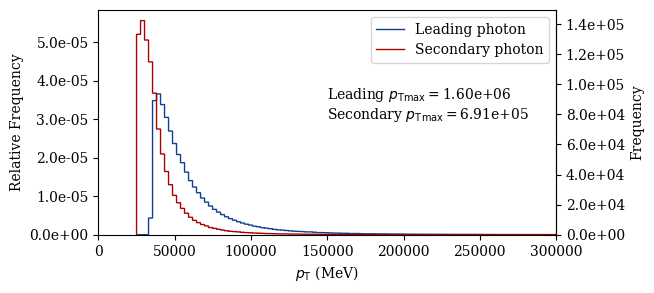

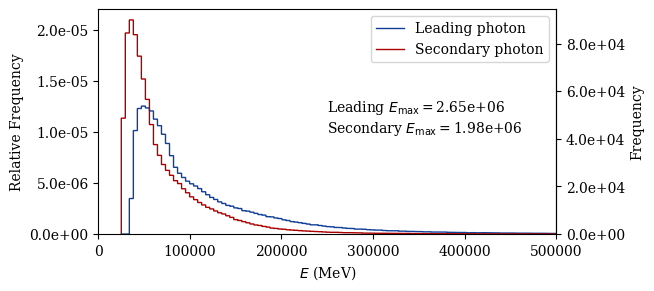

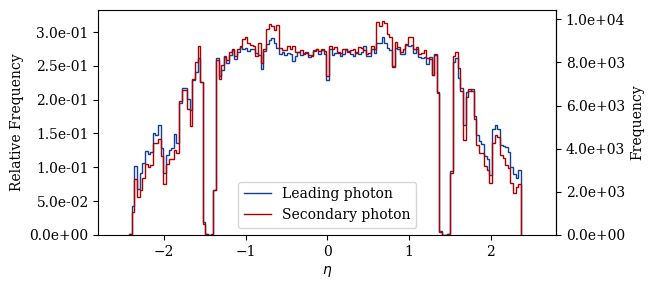

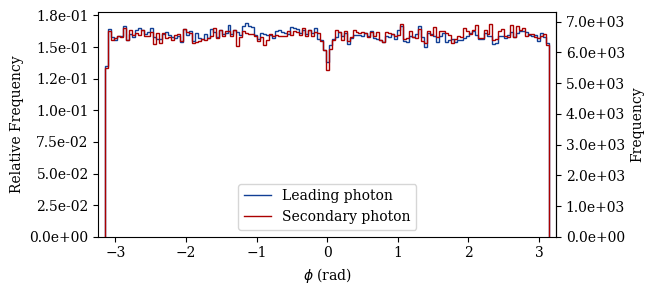

In [61]:
RED = "#AB0000"
BLUE = "#113F95"
PURPLE = "#22004E"

for data, variable, unit, bin_num, savename in zip([orig_pt, orig_E, orig_eta, orig_phi],
                                    [r"$p_\text{T}$", r"$E$", r"$\eta$", r"$\phi$"],
                                    ["(MeV)", "(MeV)", "", "(rad)"],
                                    [600, 600, 150, 150],
                                    ["pt", "E", "eta", "phi"]):    
    fig, ax = plt.subplots(figsize=get_figsize(wf=1, hf_mult=0.8))

    bins = np.linspace(np.amin(data), np.amax(data), bin_num)

    n1_dense, bins1_dense = np.histogram(data[:,0], bins=bins, density=True)
    n2_dense, bins2_dense = np.histogram(data[:,1], bins=bins, density=True)

    ax.stairs(n1_dense, bins1_dense, color=BLUE, label="Leading photon")
    ax.stairs(n2_dense, bins2_dense, color=RED, label="Secondary photon")

    def density_to_count(x):
        return x * (len(data[:,0]) * np.diff(bins)[-1])

    def count_to_density(x):
        return x / (len(data[:,0]) * np.diff(bins)[-1])

    ax2 = ax.secondary_yaxis(location="right", functions=(density_to_count, count_to_density))

    formatter = matplotlib.ticker.FormatStrFormatter('%.1e')
    ax.yaxis.set_major_formatter(formatter)
    ax2.yaxis.set_major_formatter(formatter)

    loc = "best"
    if variable == r"$p_\text{T}$":
        xlim = [0, 300000]
        xtext = 150000
        ytext = 3e-5
        maxstr = r"${"+variable[1:-1]+r"}_\text{max}=$"
        ax.text(xtext, ytext, r"Leading "+maxstr+f"{np.amax(data[:,0]):.2e}\n"+
                            r"Secondary "+maxstr+f"{np.amax(data[:,1]):.2e}")
    elif variable == r"$E$":
        xlim = [0, 500000]
        xtext = 250000
        ytext = 1e-5
        maxstr = r"${"+variable[1:-1]+r"}_\text{max}=$"
        ax.text(xtext, ytext, r"Leading "+maxstr+f"{np.amax(data[:,0]):.2e}\n"+
                            r"Secondary "+maxstr+f"{np.amax(data[:,1]):.2e}")
    elif unit == "(rad)":
        xlim = [-np.pi-0.1, np.pi+0.1]
        loc = "lower center"
    else:
        xlim = [-2.8, 2.8]

    ax.set(xlim=xlim,
        xlabel=variable+" "+unit,
        ylabel="Relative Frequency")
    ax2.set(ylabel="Frequency")

    ax.legend(loc=loc)
    # fig.savefig(f"report_results/report_plots/{savename}_orig_distributions.png",
    #             bbox_inches='tight',
    #             pad_inches=0)
    
    plt.show()
    plt.close()



In [4]:
def minmax(arr):
    return (arr - min(arr))/(max(arr) - min(arr))

def log_minmax(arr):
    return (np.log10(arr) - np.log10(min(arr)))/(np.log10(max(arr)) - np.log10(min(arr)))

calcing minmax...
(975727, 8)
(975727, 2)
Norms calculated
Plotting...


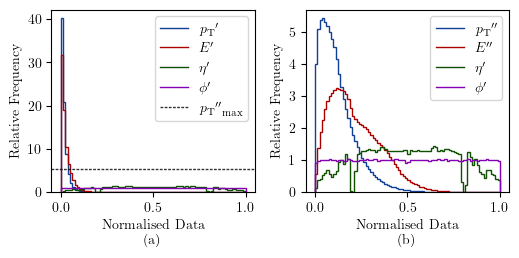

In [331]:
params = {'backend': 'Agg',
          'axes.labelsize': 10,
          "axes.titlesize": 10,
          'font.size': 10,
          "text.usetex": True,
          "font.family": "serif",
          } # extend as needed
matplotlib.rcParams.update(params)

GREEN = "#0F5100"
PURPLE = "#8300B3"
fig, axs = plt.subplots(ncols = 2, figsize=get_figsize(wf=1, hf_mult=0.65))
plt.subplots_adjust(wspace=0.25)

# for ax in axs.flatten():
#     formatter = matplotlib.ticker.FormatStrFormatter('%.2e')
#     ax.yaxis.set_major_formatter(formatter)

ax1, ax2 = axs.flatten()

print("calcing minmax...")
norm_arrs = np.column_stack([minmax(arr)  for arrs in [orig_pt, orig_E, orig_eta, orig_phi] for arr in arrs.T])
log_norm_arrs = np.column_stack([log_minmax(arr)  for arrs in [orig_pt, orig_E] for arr in arrs.T])

print(norm_arrs.shape)
print(orig_pt.shape)
print("Norms calculated\nPlotting...")
  
bin_num = 80

pt_n, bins = np.histogram(norm_arrs[:,:2], bins=bin_num, density=True)
E_n, _ = np.histogram(norm_arrs[:,2:4], bins=bin_num, density=True)
eta_n, _ = np.histogram(norm_arrs[:,4:6], bins=bin_num, density=True)
phi_n, _ = np.histogram(norm_arrs[:,6:8], bins=bin_num, density=True)
log_pt_n, _ = np.histogram(log_norm_arrs[:,:2], bins=bin_num, density=True)
log_E_n, _ = np.histogram(log_norm_arrs[:,2:4], bins=bin_num, density=True)

ax1.stairs(pt_n, bins, color=BLUE, label=r"${p_\mathrm{T}}^\prime$")
ax1.stairs(E_n, bins, color=RED, label=r"$E^\prime$")
ax1.stairs(eta_n, bins, color=GREEN, label=r"$\eta^\prime$")
ax1.stairs(phi_n, bins, color=PURPLE, label=r"$\phi^\prime$")

def density_to_count(x):
    return x * (len(data[:,0]) * np.diff(bins)[-1])

def count_to_density(x):
    return x / (len(data[:,0]) * np.diff(bins)[-1])

loc = "best"

ax1.set(xlabel="Normalised Data\n(a)",
    ylabel="Relative Frequency")

ax1.axhline(np.amax([log_E_n, log_pt_n]), linewidth=1, dashes=[2, 1], color="black", alpha=0.8, label=r"${{p_\mathrm{T}}^{\prime\prime}}_\mathrm{max}$")

ax1.legend(loc=loc)

ax2.stairs(log_pt_n, bins, color=BLUE, label=r"${p_\mathrm{T}}^{\prime\prime}$")
ax2.stairs(log_E_n, bins, color=RED, label=r"$E^{\prime\prime}$")
ax2.stairs(eta_n, bins, color=GREEN, label=r"$\eta^\prime$")
ax2.stairs(phi_n, bins, color=PURPLE, label=r"$\phi^\prime$")

ax2.set(xlabel="Normalised Data\n(b)",
        ylabel="Relative Frequency")

ax2.legend()

# fig.savefig(f"report_results/report_plots/minmax_vs_log_minmax.png",
#             bbox_inches='tight',
#             pad_inches=0.05,
#             dpi=300)
plt.show()
plt.close()



7772074


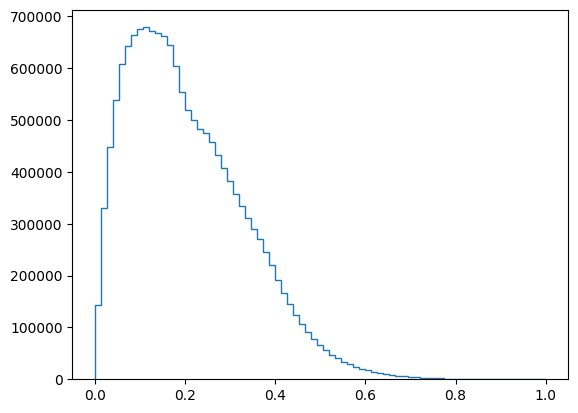

In [8]:
fig, ax = plt.subplots()

with np.load("workspaces/higgs/data/V4_precut_normalised.npz") as f:
    n, bins = np.histogram(f["data"][:,6:8], bins=75)
    print(len(f["data"]))

ax.stairs(n, bins)
plt.show()

In [5]:
from scipy.stats import skew

def calc_rmse(orig, decomp):
    rmse = np.sqrt(np.mean((orig - decomp)**2))
    nrmse = rmse / (np.amax(orig) - np.amin(orig))
    return (rmse, nrmse)

def calc_mean_std_skew(orig, decomp):
    sign = orig / abs(orig)

    epsilon = np.maximum(np.abs(orig + decomp), 0.01)

    resolutions = sign * (orig - decomp) / epsilon

    # resolutions = (orig - decomp) / (orig + decomp)

    mean_res = np.mean(resolutions)
    std_res = np.std(resolutions)
    skewness_res = skew(resolutions.flatten())

    return (mean_res, std_res, skewness_res)


In [6]:
def unnormalise_log(data, scales):
    return 10**(data*(scales[1] - scales[0])+scales[0])

def unnormalise_minmax(data, scales):
    return data*(scales[1] - scales[0]) + scales[0]

def calc_masses(pts, etas, phis, Es):
    # first photon is [0], 2nd photon is [1] etc
    px_0 = pts[:,0]*np.cos(phis[:,0]) # x-component of photon[0] momentum
    py_0 = pts[:,0]*np.sin(phis[:,0]) # y-component of photon[0] momentum
    pz_0 = pts[:,0]*np.sinh(etas[:,0]) # z-component of photon[0] momentum
    px_1 = pts[:,1]*np.cos(phis[:,1]) # x-component of photon[1] momentum
    py_1 = pts[:,1]*np.sin(phis[:,1]) # y-component of photon[1] momentum
    pz_1 = pts[:,1]*np.sinh(etas[:,1]) # z-component of photon[1] momentum
    sumpx = px_0 + px_1 # x-component of diphoton momentum
    sumpy = py_0 + py_1 # y-component of diphoton momentum
    sumpz = pz_0 + pz_1 # z-component of diphoton momentum 
    sump = np.sqrt(sumpx**2 + sumpy**2 + sumpz**2) # magnitude of diphoton momentum 
    sumE = Es[:,0] + Es[:,1] # energy of diphoton system
    return np.sqrt(abs(sumE**2 - sump**2))/1000 #/1000 to go from MeV to GeV


In [7]:
for version in ["V2", "V3", "V4", "V5"]:
    with np.load("workspaces/higgs/data/"+version+"_precut_normalised.npz") as f:
        print(f"{version}: {len(f["data"])}")

V2: 975727
V3: 647400
V4: 7772074
V5: 396373


In [8]:
def cut_IDs(IDs):
    return IDs[:,0].astype(bool) & IDs[:,1].astype(bool)

def cut_etcones(etcones):
    return (etcones[:,0] < 4000) & (etcones[:,1] < 4000)

def cut_pts(pts):
    return (pts[:,0] > 40000) & (pts[:,1] > 30000)

def cut_etas(etas):
    return (((abs(etas[:,0])>1.52) | (abs(etas[:,0])<1.37))) &  (((abs(etas[:,1])>1.52) | (abs(etas[:,1])<1.37)))

def apply_cuts(data, version, newdata=None):
    if newdata is not None:
        if version == "V2":
            with np.load("workspaces/higgs/data/photon_etcones.npz") as f:
                etcones = f["data"]
            newdata = newdata[cut_etcones(etcones) & cut_pts(data[:,:2]) & cut_etas(data[:,2:4])]
        elif version == "V3":
            newdata = newdata[cut_pts(data[:,:2]) & cut_etas(data[:,2:4])]
        elif version == "V4":
            with (np.load("workspaces/higgs/data/V4_photon_etcone20.npz") as etcone_f,
                np.load("workspaces/higgs/data/V4_photon_isTightID.npz") as ID_f):
                etcones = etcone_f["data"]
                IDs = ID_f["data"]
            newdata = newdata[cut_IDs(IDs) & cut_etcones(etcones) & cut_pts(data[:,:2]) & cut_etas(data[:,2:4])]
        return newdata
    else:
        if version == "V2":
            with np.load("workspaces/higgs/data/photon_etcones.npz") as f:
                etcones = f["data"]
            data = data[cut_etcones(etcones)]
            data = data[cut_pts(data[:,:2])]
            data = data[cut_etas(data[:,2:4])]
        elif version == "V3":
            data = data[cut_pts(data[:,:2])]
            data = data[cut_etas(data[:,2:4])]
        elif version == "V4":
            with (np.load("workspaces/higgs/data/V4_photon_etcone20.npz") as etcone_f,
                np.load("workspaces/higgs/data/V4_photon_isTightID.npz") as ID_f):
                etcones = etcone_f["data"]
                IDs = ID_f["data"]
            data = data[cut_IDs(IDs) & cut_etcones(etcones)]
            data = data[cut_pts(data[:,:2])]
            data = data[cut_etas(data[:,2:4])]
        return data
        

In [9]:
version = "V2"
current_path = version+"_results/V"
filename = "/decompressed.npz"

with (np.load("workspaces/higgs/data/"+version+"_precut_original.npz") as orig_file,
      np.load("workspaces/higgs/data/"+version+"_precut_scales.npz") as scale_file):
    raw_orig = orig_file["data"]
    scales = scale_file["data"]
    orig = apply_cuts(raw_orig, version)
    print(len(orig))
    orig_masses = calc_masses(orig[:,:2], orig[:,2:4], orig[:,4:6], orig[:,6:8])

pt_rmses = []
pt_nrmses = []
pt_means = []
pt_stds = []
pt_skews = []
eta_rmses = []
eta_nrmses = []
eta_means = []
eta_stds = []
eta_skews = []
phi_rmses = []
phi_nrmses = []
phi_means = []
phi_stds = []
phi_skews = []
E_rmses = []
E_nrmses = []
E_means = []
E_stds = []
E_skews = []
mass_rmses = []
mass_nrmses = []
mass_means = []
mass_stds = []
mass_skews = []

all_masses = []

for i in range(8):
    with np.load(current_path+str(i+1)+filename) as datafile:
        data = datafile["data"]

        pts = np.column_stack([unnormalise_log(pt, scale) for pt, scale in zip(data[:,:2].T, scales[:,:2])])
        etas = np.column_stack([unnormalise_minmax(eta, scale) for eta, scale in zip(data[:,2:4].T, scales[:,2:4])])
        phis = np.column_stack([unnormalise_minmax(phi, scale) for phi, scale in zip(data[:,4:6].T, scales[:,4:6])])
        Es = np.column_stack([unnormalise_log(E, scale) for E, scale in zip(data[:,6:8].T, scales[:,6:8])])
        
        data = apply_cuts(raw_orig, version, np.column_stack([pts, etas, phis, Es]))
        pts, etas, phis, Es = data[:,:2], data[:,2:4], data[:,4:6], data[:,6:8]
        if i == 0:
            print(f"Data length: {len(data)}")
            first_pts = pts
            first_Es = Es
        masses = calc_masses(pts, etas, phis, Es)
        all_masses.append(masses)

        (pt_rmse, pt_nrmse) = calc_rmse(orig[:,:2], pts)
        (pt_mean, pt_std, pt_skew) = calc_mean_std_skew(orig[:,:2], pts)
        (eta_rmse, eta_nrmse) = calc_rmse(orig[:,2:4], etas)
        (eta_mean, eta_std, eta_skew) = calc_mean_std_skew(orig[:,2:4], etas)
        (phi_rmse, phi_nrmse) = calc_rmse(orig[:,4:6], phis)
        (phi_mean, phi_std, phi_skew) = calc_mean_std_skew(orig[:,4:6], phis)
        (E_rmse, E_nrmse) = calc_rmse(orig[:,6:8], Es)
        (E_mean, E_std, E_skew) = calc_mean_std_skew(orig[:,6:8], Es)
        (mass_rmse, mass_nrmse) = calc_rmse(orig_masses, masses)
        (mass_mean, mass_std, mass_skew) = calc_mean_std_skew(orig_masses, masses)

        pt_rmses.append(pt_rmse)
        pt_nrmses.append(pt_nrmse)
        pt_means.append(pt_mean)
        pt_stds.append(pt_std)
        pt_skews.append(pt_skew)

        eta_rmses.append(eta_rmse)
        eta_nrmses.append(eta_nrmse)
        eta_means.append(eta_mean)
        eta_stds.append(eta_std)
        eta_skews.append(eta_skew)

        phi_rmses.append(phi_rmse)
        phi_nrmses.append(phi_nrmse)
        phi_means.append(phi_mean)
        phi_stds.append(phi_std)
        phi_skews.append(phi_skew)

        E_rmses.append(E_rmse)
        E_nrmses.append(E_nrmse)
        E_means.append(E_mean)
        E_stds.append(E_std)
        E_skews.append(E_skew)

        mass_rmses.append(mass_rmse)
        mass_nrmses.append(mass_nrmse)
        mass_means.append(mass_mean)
        mass_stds.append(mass_std)
        mass_skews.append(mass_skew)

print(f"{version} Variables & RMSE & NRMSE & $\\mu$ & $\\sigma$ & $\\gamma_1$ \\\\")
print("\\hline")
print(f"$p_\\text{{T}}$ (MeV) & {np.mean(pt_rmses):.5f} & {np.mean(pt_nrmses):.5f} & {np.mean(pt_means):.5f} & {np.mean(pt_stds):.5f} & {np.mean(pt_skews):.5f} \\\\")
print(f"$\\eta$ & {np.mean(eta_rmses):.5f} & {np.mean(eta_nrmses):.5f} & {np.mean(eta_means):.5f} & {np.mean(eta_stds):.5f} & {np.mean(eta_skews):.5f} \\\\")
print(f"$\\phi$ (rad) & {np.mean(phi_rmses):.5f} & {np.mean(phi_nrmses):.5f} & {np.mean(phi_means):.5f} & {np.mean(phi_stds):.5f} & {np.mean(phi_skews):.5f} \\\\")
print(f"$E$ (MeV) & {np.mean(E_rmses):.5f} & {np.mean(E_nrmses):.5f} & {np.mean(E_means):.5f} & {np.mean(E_stds):.5f} & {np.mean(E_skews):.5f} \\\\")
print(f"$m_{{\\gamma\\gamma}}$ (GeV) & {np.mean(mass_rmses):.5f} & {np.mean(mass_nrmses):.5f} & {np.mean(mass_means):.5f} & {np.mean(mass_stds):.5f} & {np.mean(mass_skews):.5f} \\\\")
print("\\hline")

all_masses = np.vstack(all_masses)
all_orig_masses = np.vstack([orig_masses]*8)


396373
Data length: 396373
V2 Variables & RMSE & NRMSE & $\mu$ & $\sigma$ & $\gamma_1$ \\
\hline
$p_\text{T}$ (MeV) & 87.12179 & 0.00009 & 0.00003 & 0.00054 & -0.26750 \\
$\eta$ & 0.00090 & 0.00019 & 0.00000 & 0.00543 & 11.61165 \\
$\phi$ (rad) & 0.00126 & 0.00020 & 0.00001 & 0.00629 & 16.82868 \\
$E$ (MeV) & 308.10916 & 0.00013 & 0.00001 & 0.00088 & 0.71893 \\
$m_{\gamma\gamma}$ (GeV) & 2.24681 & 0.00092 & 0.00038 & 0.02830 & 5.71549 \\
\hline


In [10]:


pt_res = (orig[:,0] - first_pts[:,0]) / (orig[:,0] + first_pts[:,0])
E_res = (orig[:,6] - first_Es[:,0]) / (orig[:,6] + first_Es[:,0])
fig = corner.corner(np.column_stack([pt_res, E_res]), figsize=get_figsize(), bins=150)
axs = fig.get_axes()
axs[0].set(xlim=(-0.006, 0.006),
           ylabel=r"Leading photon $p_\mathrm{T}$")
axs[2].set(xlim=(-0.006, 0.006), ylim=(-0.006, 0.006))
axs[3].set(xlim=(-0.006, 0.006),
           xlabel=r"Leading photon $E$")

axs[1].set(xlim=(0,1),ylim=(0,1))
# axs[1].text(0.15, 0.4, r"Resolution = $\displaystyle\frac{x_i-\widehat{x}_i}{x_i+\widehat{x}_i}$"+
#             "\n\n"+r"Skew $p_\mathrm{T}=$"+f"{skew(pt_res):.3f}\nSkew "+r"$E=$"+f"{skew(E_res):.3f}")
axs[0].text(axs[0].get_xlim()[0]*0.95, axs[0].get_ylim()[1]*0.9, rf"$\gamma_1={skew(pt_res):.3f}$")
axs[3].text(axs[3].get_xlim()[0]*0.95, axs[3].get_ylim()[1]*0.9, rf"$\gamma_1={skew(E_res):.3f}$")

plt.show()
# plt.savefig()
plt.close()


NameError: name 'get_figsize' is not defined

In [13]:
matplotlib.rcParams.update({"backend": "Agg"})

# fig, axs = plt.subplots(ncols=3, figsize=get_figsize(hf_mult=0.5, wf=2))
fig, axs = plt.subplots(ncols=4, figsize=(9,3))

ax1, ax2, ax3, ax4 = axs.flatten()

differences = orig_masses - masses
norm_diffs = differences / (max(orig_masses) - min(orig_masses))
resolutions1 = differences / (orig_masses)
resolutions2 = differences / (orig_masses + masses)

n1, bins1 = np.histogram(differences, bins=100)
n2, bins2 = np.histogram(norm_diffs, bins=100)
n3, bins3 = np.histogram(resolutions1, bins=100)
n4, bins4 = np.histogram(resolutions2, bins=100)

ax1.stairs(n1, bins1)
ax2.stairs(n2, bins2)
ax3.stairs(n3, bins3)
ax4.stairs(n4, bins4)

ax1.set(title="Residual",
        xlabel=r"$ m_{\gamma\gamma} - \widehat{m}_{\gamma\gamma}$",
        ylabel="Frequency",
        yscale="log",
        xlim=[-np.amax(np.abs(ax1.get_xlim())), np.amax(np.abs(ax1.get_xlim()))],
        )
ax2.set(title="Normalised residual",
        xlabel=r"$\frac{m_{\gamma\gamma} - \widehat{m}_{\gamma\gamma}}{m_\mathrm{max} - m_\mathrm{min}}$",
        ylabel="Frequency",
        yscale="log",
        xlim=[-np.amax(np.abs(ax2.get_xlim())), np.amax(np.abs(ax2.get_xlim()))],
        )
ax3.set(title="Original resolution",
        xlabel=r"$\frac{m_{\gamma\gamma} - \widehat{m}_{\gamma\gamma}}{m_{\gamma\gamma}}$",
        ylabel="Frequency",
        yscale="log",
        xlim=[-np.amax(np.abs(ax3.get_xlim())), np.amax(np.abs(ax3.get_xlim()))],
        )
ax4.set(title="Resolution I'm proposing",
        xlabel=r"$\frac{m_{\gamma\gamma} - \widehat{m}_{\gamma\gamma}}{m_{\gamma\gamma} + \widehat{m}_{\gamma\gamma}}$",
        ylabel="Frequency",
        yscale="log",
        xlim=[-np.amax(np.abs(ax4.get_xlim())), np.amax(np.abs(ax4.get_xlim()))],
        )
# plt.subplots_adjust(wspace=0.25)
fig.tight_layout()
fig.savefig("residual_resolution_comparison.png", pad_inches=2, dpi=800)
# plt.show()
plt.close()
print(skew(differences.flatten()), skew(norm_diffs.flatten()), skew(resolutions1.flatten()), skew(resolutions2.flatten()))
# print(np.amin(resolutions), np.amax(resolutions))
# print(np.amin(all_orig_masses), np.amax(all_orig_masses))

6.635445594787598 6.635447025299072 -11.479145050048828 6.262123107910156


In [112]:
7/8

0.875

In [5]:
v1_kls = [1.2736257298755444e-05, 1.4999707311036072e-06, 2.284136233582345e-06, 1.7883777983401068e-05, 1.339941294190437e-05, 1.1554585345646876e-05, 8.41013492907774e-06]
v2_kls = [4.475321793778893e-06, 6.229797242445506e-07, 6.438296658534457e-06, 4.383314114443957e-06, 4.393478901482933e-06, 2.821979405660596e-06, 1.3575609375971512e-05]
v3_kls = [2.602268782980302e-06, 1.535482202076396e-06, 7.571196055442957e-06, 6.153039439969476e-06, 1.4862470185476173e-06, 6.735360072522236e-06, 3.870250765085619e-06]
v4_kls = [1.6012071316045661e-06, 8.577285792813375e-06, 5.843784178543427e-05, 3.084219752321717e-05, 1.1027628478314246e-05, 1.095367547231056e-06, 1.1241874098306888e-05, 5.283859199752434e-05]

for v, kls in zip(["v1", "v2", "v3", "v4"], [v1_kls, v2_kls, v3_kls, v4_kls]):
    # if v == "v4":
    #     print((np.sum(kls)-max(kls))/7)
    print(f"{v}: {len(kls)}, {np.mean(kls):.4e}, {np.std(kls):.4e}, {np.amax(kls):.4e}, {np.amin(kls):.4e}")



v1: 7, 9.6812e-06, 5.5705e-06, 1.7884e-05, 1.5000e-06
v2: 7, 5.2444e-06, 3.7819e-06, 1.3576e-05, 6.2298e-07
v3: 7, 4.2791e-06, 2.3510e-06, 7.5712e-06, 1.4862e-06
v4: 8, 2.1958e-05, 2.1291e-05, 5.8438e-05, 1.0954e-06


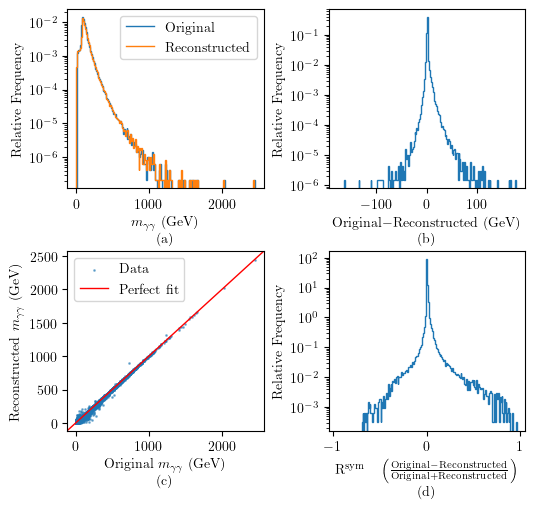

5.47471067672172
5.90551196900512


In [64]:
#### Plot Resolutions
%matplotlib inline
# matplotlib.rcParams.update({"backend": "macosx"})
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=get_figsize(hf_mult=1.5))
plt.subplots_adjust(wspace=0.33, hspace=0.35)

ax1, ax2, ax3, ax4 = axs.flatten()

n_orig, bins_orig = np.histogram(orig_masses, bins=200, density=True)
n_dec, bins_dec = np.histogram(masses, bins=200, density=True)

diffs = orig_masses - masses
n_diff, bins_diff = np.histogram(diffs, bins=200, density=True)

resols = diffs / (orig_masses + masses)
n_res, bins_res = np.histogram(resols, bins=200, density=True)

ax1.stairs(n_orig, bins_orig, label="Original")
ax1.stairs(n_dec, bins_dec, label="Reconstructed")

ax2.stairs(n_diff, bins_diff)

ax3.scatter(orig_masses, masses, s=1, alpha=0.5, label="Data")
ax3_line = ax3.get_xlim()
ax3.plot(ax3_line, ax3_line, c="r", linewidth=1, zorder=2, label="Perfect fit")

ax4.stairs(n_res, bins_res)

# lims_diffs = [np.percentile(diffs, 0.05), np.percentile(diffs, 99.95)]
# lims_diffs = [-np.amax(np.abs(lims_diffs)), np.amax(np.abs(lims_diffs))]
lims_diffs = [-np.amax(np.abs(ax2.get_xlim())), np.amax(np.abs(ax2.get_xlim()))]
lims_res = [np.percentile(resols, 0.08), np.percentile(resols, 99.92)]
lims_res = [-np.amax(np.abs(lims_res)), np.amax(np.abs(lims_res))]
lims_res = [-np.amax(np.abs(ax4.get_xlim())), np.amax(np.abs(ax4.get_xlim()))]

ax1.set(xlabel=r"$m_{\gamma\gamma}$ (GeV)"+
        "\n(a)",
        ylabel="Relative Frequency",
        yscale="log",
        )
ax2.set(xlabel=r"Original$-$Reconstructed (GeV)"+
        "\n(b)",
        ylabel="Relative Frequency",
        yscale="log",
        xlim=lims_diffs,
        )
ax3.set(xlabel=r"Original $m_{\gamma\gamma}$ (GeV)"+
        "\n(c)",
        ylabel=r"Reconstructed $m_{\gamma\gamma}$ (GeV)",
        xlim=ax3_line,
        ylim=ax3_line,
        )
ax4.set(xlabel=r"$\mathrm{R}^\mathrm{sym}\quad\left(\frac{\mathrm{Original}-\mathrm{Reconstructed}}{\mathrm{Original}+\mathrm{Reconstructed}}\right)$"+
        "\n(d)",
        ylabel="Relative Frequency",
        yscale="log",
        xlim=lims_res,
        )

for ax in axs.flatten()[::2]:
    ax.legend()

plt.show()
matplotlib.rcParams.update({"backend": "Agg"})
print(fig.get_figheight())
print(fig.get_figwidth())
fig.savefig("mass_resolutions_example.png", dpi=300, bbox_inches="tight")
plt.close()



In [71]:
l = [1, 2, 3]
l+=[5, 6]
print(l)


[1, 2, 3, 5, 6]


In [90]:
loss_data = np.load("workspaces/higgs/higgs_project/output/training/loss_data.npy")
train_loss = loss_data[0]
val_loss = loss_data[1]


plt.figure(figsize=get_figsize())
# plt.title("Loss plot")
plt.plot(train_loss, color="orange", label="Train Loss")
plt.plot(val_loss, color="red", label="Validation Loss")

plt.xlabel("Epochs")
plt.yscale("log")
plt.ylabel("Loss")
plt.legend(loc="best")
plt.savefig("Loss_plot_example.png", dpi=300, bbox_inches="tight")
# plt.show()
plt.close()



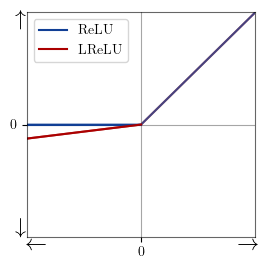

In [162]:
RED = "#AB0000"
BLUE = "#113F95"

fig, ax = plt.subplots(figsize=get_figsize(wf=0.5, hf_mult=1.6))

ax.plot([-1.2,0,1.2], [-0.15, 0, 1.2], c=RED, alpha=0.7)
ax.plot([-1.2,0,1.2], [0,0,1.2], c=BLUE, alpha=0.7)
ax.plot([-1.2, 0], [0,0], c=BLUE, label="ReLU")
ax.plot([-1.2, 0], [-0.15, 0], c=RED, label="LReLU")
ax.grid(color="gray", alpha=0.7)
# ax.set(xticks=[-1, 0, 1],
#        xticklabels=[r"$\leftarrow$", 0, r"$\rightarrow$"],
#        yticks=[-1, 0, 1],
#        yticklabels=[r"$\downarrow$", 0, r"$\uparrow$"],
#        xlim=[-1, 1],
#        ylim=[-1, 1])

# plt.show()
# plt.close()

# Set ticks only at 0
ax.set_xticks([0])
ax.set_yticks([0])
ax.set_xticklabels([r"$0$"])
ax.set_yticklabels([r"$0$"])

# Set axis limits to extend arrows
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])

# Remove default spines and add custom arrows
for spine in ["left", "bottom", "right", "top"]:
    ax.spines[spine].set_alpha(0.6)

# # Draw longer custom arrows
# ax.plot([1.15], [0], ">k", transform=ax.get_yaxis_transform(), clip_on=False)
# ax.plot([0], [1.15], "^k", transform=ax.get_xaxis_transform(), clip_on=False)

# Add arrow labels
ax.text(1.02, -1.38, r"$\mathbf{\rightarrow}$", fontsize=16)
ax.text(-1.32, 1.06, r"$\mathbf{\uparrow}$", fontsize=16)
ax.text(-1.21, -1.38, r"$\mathbf{\leftarrow}$", fontsize=16)
ax.text(-1.32, -1.16, r"$\mathbf{\downarrow}$", fontsize=16)

ax.legend()


plt.savefig("LReLU_example.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()


In [214]:
def unnormalise_log(data, scales):
    return 10**(data*(scales[1] - scales[0])+scales[0])

def cut_IDs(IDs):
    return IDs[:,0].astype(bool) & IDs[:,1].astype(bool)

def cut_etcones(etcones):
    return (etcones[:,0] < 4000) & (etcones[:,1] < 4000)

def cut_pts(pts):
    return (pts[:,0] > 40000) & (pts[:,1] > 30000)

def cut_etas(etas):
    return (((abs(etas[:,0])>1.52) | (abs(etas[:,0])<1.37))) &  (((abs(etas[:,1])>1.52) | (abs(etas[:,1])<1.37)))
version = "V4"
def apply_cuts(data, newdata=None):
    if newdata is not None:
        if version == "V2":
            with np.load("workspaces/higgs/data/photon_etcones.npz") as f:
                etcones = f["data"]
            newdata = newdata[cut_etcones(etcones) & cut_pts(data[:,:2]) & cut_etas(data[:,2:4])]
        elif version == "V3":
            newdata = newdata[cut_pts(data[:,:2]) & cut_etas(data[:,2:4])]
        elif version == "V4":
            with (np.load("workspaces/higgs/data/V4_photon_etcone20.npz") as etcone_f,
                np.load("workspaces/higgs/data/V4_photon_isTightID.npz") as ID_f):
                etcones = etcone_f["data"]
                IDs = ID_f["data"]
            newdata = newdata[cut_IDs(IDs) & cut_etcones(etcones) & cut_pts(data[:,:2]) & cut_etas(data[:,2:4])]
        return newdata
    else:
        if version == "V2":
            with np.load("workspaces/higgs/data/photon_etcones.npz") as f:
                etcones = f["data"]
            data = data[cut_etcones(etcones)]
            data = data[cut_pts(data[:,:2])]
            data = data[cut_etas(data[:,2:4])]
        elif version == "V3":
            data = data[cut_pts(data[:,:2])]
            data = data[cut_etas(data[:,2:4])]
        elif version == "V4":
            with (np.load("workspaces/higgs/data/V4_photon_etcone20.npz") as etcone_f,
                np.load("workspaces/higgs/data/V4_photon_isTightID.npz") as ID_f):
                etcones = etcone_f["data"]
                IDs = ID_f["data"]
            data = data[cut_IDs(IDs) & cut_etcones(etcones)]
            data = data[cut_pts(data[:,:2])]
            data = data[cut_etas(data[:,2:4])]
        return data


[4.5622589 4.5622589]


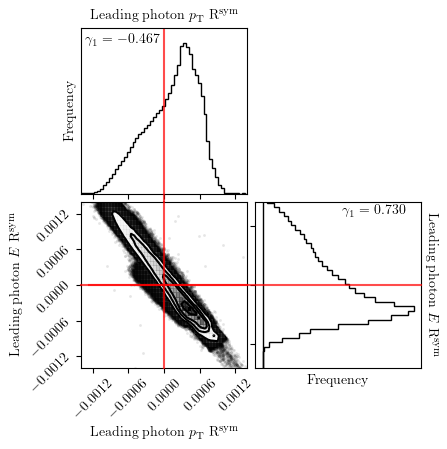

In [ ]:

# fig = plt.figure(figsize=get_figsize())
with (np.load("V4_results/V3/decompressed.npz") as f,
      np.load("workspaces/higgs/data/V4_precut_scales.npz") as s,
      np.load("workspaces/higgs/data/V4_precut_original.npz") as o):
    raw_orig = o["data"]
    orig = apply_cuts(raw_orig)
    orig_pts = orig[:,0]
    orig_Es = orig[:,-2]
    data = f["data"]
    scales = s["data"]

    pts = np.column_stack([unnormalise_log(pt, scale) for pt, scale in zip(data[:,:2].T, scales[:,:2])])
    etas = np.column_stack([unnormalise_minmax(eta, scale) for eta, scale in zip(data[:,2:4].T, scales[:,2:4])])
    phis = np.column_stack([unnormalise_minmax(phi, scale) for phi, scale in zip(data[:,4:6].T, scales[:,4:6])])
    Es = np.column_stack([unnormalise_log(E, scale) for E, scale in zip(data[:,6:8].T, scales[:,6:8])])
    
    data = apply_cuts(raw_orig, np.column_stack([pts, etas, phis, Es]))
    pts, etas, phis, Es = data[:,:2], data[:,2:4], data[:,4:6], data[:,6:8]
    del raw_orig
    del data
    pt_res = (orig_pts - pts[:,0])/(orig_pts + pts[:,0])
    E_res = (orig_Es - Es[:,0])/(orig_Es + Es[:,0])

label="Leading"

# fig, ax = plt.subplots()
# ax.scatter(orig_pts, pts, s=2, alpha=0.5)
size = get_figsize()
size=(size[1]*1.25, size[1]*1.25)
fig = plt.figure(figsize=size)
fig = corner.corner(np.column_stack((pt_res, E_res)), bins=300, fig=fig)
axs = fig.get_axes()

percentiles = (np.percentile(pt_res, 0.5), np.percentile(pt_res, 99.5), np.percentile(E_res, 0.5), np.percentile(E_res, 99.5))
maxi = np.amax(np.abs(percentiles))
lims = (-maxi, maxi)
axs[0].tick_params(labelleft=True)           # Show y-axis ticks
axs[3].tick_params(labelleft=False)

axs[0].set(title=rf"{label} photon $p_\mathrm{{T}} \ \mathrm{{R}}^\mathrm{{sym}}$",
            ylabel="Frequency",
            xlim=lims)
axs[2].set(ylabel=rf"{label} photon $E \ \mathrm{{R}}^\mathrm{{sym}}$",
            xlabel=rf"{label} photon $p_\mathrm{{T}} \ \mathrm{{R}}^\mathrm{{sym}}$",
            xlim=lims,
            ylim=lims)

axs[3].clear()
n, bins = np.histogram(E_res, bins=300)
axs[3].stairs(bins[1:-1], n, color="k")
axs[3].set(xticks=[], xticklabels=[], yticklabels=[], ylim=lims)

# Set labels and ticks AFTER clearing
axs[3].set_xlabel("Frequency", labelpad=5)
axs[3].set_ylabel(rf"{label} photon $E \ \mathrm{{R}}^\mathrm{{sym}}$", labelpad=5, rotation=270)
axs[3].tick_params(labelbottom=True, labelright=True, labelleft=False)

# Optional: adjust tick positions or style
axs[3].yaxis.set_label_position("right")

axs[0].text(lims[0]*0.95, axs[0].get_ylim()[1]*0.91,
            rf"$\gamma_1={skew(pt_res):.3f}$")    
axs[3].text(axs[3].get_xlim()[1]*0.5, lims[1]*0.85,
            rf"$\gamma_1={skew(E_res):.3f}$")

axs[0].axvline(x=0, ymin=-1, ymax=0.99, c="r", linewidth=1.5, zorder=10, clip_on=False, alpha=0.7)
axs[2].axvline(x=0, ymin=0, ymax=1, c="r", linewidth=1.5, zorder=10, clip_on=False, alpha=0.7)
axs[2].axhline(y=0, xmin=0, xmax=1, c="r", linewidth=1.5, zorder=10, clip_on=False, alpha=0.7)
axs[3].axhline(y=0, xmin=-1, xmax=1, c="r", linewidth=1.5, zorder=10, clip_on=False, alpha=0.7)

print(fig.get_size_inches())

plt.savefig("report_corner_graph.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
from scipy.stats import chisquare, entropy
from V3_results.V3_calc_masses_and_plot import zvalue_poisson

def plot_both_data(orig_data):   

    xmin = 100 # GeV
    xmax = 160 # GeV
    step_size = 3 # GeV
    
    bin_edges = np.arange(start=xmin, # The interval includes this value
                     stop=xmax+step_size, # The interval doesn't include this value
                     step=step_size ) # Spacing between values
    bin_centres = np.arange(start=xmin+step_size/2, # The interval includes this value
                            stop=xmax+step_size/2, # The interval doesn't include this value
                            step=step_size ) # Spacing between values

    orig_data_x,binss = np.histogram(orig_data, 
                            bins=bin_edges) # histogram the data
    orig_data_x_errors = np.sqrt(orig_data_x) # statistical error on the data

    # data fit
    orig_polynomial_mod = PolynomialModel( 4 ) # 4th order polynomial
    orig_gaussian_mod = GaussianModel() # Gaussian

    # set initial guesses for the parameters of the polynomial model
    # c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
    orig_pars = orig_polynomial_mod.guess(orig_data_x, # data to use to guess parameter values
                                x=bin_centres, c0=orig_data_x.max(), c1=0,
                                c2=0, c3=0, c4=0 )
    
    # set initial guesses for the parameters of the Gaussian model
    orig_pars += orig_gaussian_mod.guess(orig_data_x, # data to use to guess parameter values
                               x=bin_centres, amplitude=100, 
                               center=125, sigma=2 )
    
    orig_model = orig_polynomial_mod + orig_gaussian_mod # combined model
    
    # fit the model to the data
    orig_out = orig_model.fit(orig_data_x, # data to be fit
                    orig_pars, # guesses for the parameters
                    x=bin_centres, weights=1/orig_data_x_errors ) 

    # background part of fit
    orig_params_dict = orig_out.params.valuesdict() # get the parameters from the fit to data

    cs = ["c0", "c1", "c2", "c3", "c4"]
    
    # get the background only part of the fit to data
    orig_background = np.sum([orig_params_dict[c_val]*(bin_centres**i) for i, c_val in enumerate(cs)], axis=0)

    # data fit - background fit = signal fit
    orig_signal_x = orig_data_x - orig_background 

    # Calculating z-values
    orig_fit = orig_out.best_fit

    orig_peak_bin_idxs = np.where(abs(orig_fit - orig_background > 1))[0]
    orig_z = zvalue_poisson(sum(orig_fit[orig_peak_bin_idxs]), sum(orig_background[orig_peak_bin_idxs]))
    orig_big_z = zvalue_poisson(sum(orig_fit), sum(orig_background))
    # orig_z = sum(np.vectorize(zvalue_poisson)(orig_fit, orig_background))

    # Calculating Chisquare

    orig_bk_chi_val = orig_background * (sum(orig_data_x)/sum(orig_background))
    orig_fit_chi_val = orig_fit * (sum(orig_data_x)/sum(orig_fit))

    bk_dof = len(orig_data_x) - 5
    fit_dof = len(orig_data_x) - len(orig_params_dict.keys())

    orig_bk_chi = chisquare(orig_bk_chi_val, orig_data_x).statistic / bk_dof
    orig_fit_chi = chisquare(orig_fit_chi_val, orig_data_x).statistic / fit_dof

    # *************
    # Main plot 
    # *************
    plt.axes([0.1,0.3,0.85,0.65]) # left, bottom, width, height 
    main_axes = plt.gca() # get current axes
    
    #ORIGINAL
    # plot the original data points
    main_axes.errorbar(x=bin_centres, y=orig_data_x, yerr=orig_data_x_errors,
                       color="#8B0000",
                       marker='o', # 'k' means black and 'o' means circles
                       markersize=3,
                       label='Original Data',
                       zorder=1,
                       alpha=0.6,
                       linestyle="None") 
    
    # plot the signal + background fit
    main_axes.plot(bin_centres, # x
                   orig_fit, # y
                   '-r', # single red line
                   label=f'Original Sig+Bkg Fit ($m_H={orig_params_dict["center"]:.2f}$ GeV)',
                   linewidth=1,
                   alpha=0.6)
    
    # plot the background only fit
    main_axes.plot(bin_centres, # x
                   orig_background, # y
                   '--r', # dashed red line
                   label='Original Bkg (4th order polynomial)',
                   linewidth=1,
                   alpha=0.6)
    

    # set the x-limit of the main axes
    main_axes.set_xlim( left=xmin, right=xmax ) 
    
    # separation of x-axis minor ticks
    main_axes.xaxis.set_minor_locator( AutoMinorLocator() ) 
    
    # set the axis tick parameters for the main axes
    main_axes.tick_params(which='both', # ticks on both x and y axes
                          direction='in', # Put ticks inside and outside the axes
                          top=True, # draw ticks on the top axis
                          labelbottom=False, # don't draw tick labels on bottom axis
                          right=True ) # draw ticks on right axis
    
    # write y-axis label for main axes
    main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                         horizontalalignment='right',
                         ) 
    
    # set the y-axis limit for the main axes
    main_axes.set_ylim( bottom=0, top=np.amax(orig_data_x)*1.1 ) 
    
    # set minor ticks on the y-axis of the main axes
    main_axes.yaxis.set_minor_locator( AutoMinorLocator() ) 
    
    # avoid displaying y=0 on the main axes
    main_axes.yaxis.get_major_ticks()[0].set_visible(False) 

    # Add text 'ATLAS Open Data' on plot
    plt.text(0.4, # x
             0.89, # y
             'ATLAS Open Data', # text
             transform=main_axes.transAxes, # coordinate system used is that of main_axes
             fontsize=13 ) 
    
    # Add text 'for education' on plot
    plt.text(0.4, # x
             0.83, # y
             'for education', # text
             transform=main_axes.transAxes, # coordinate system used is that of main_axes
             style='italic',
             fontsize=8 ) 
    
    # Add energy and luminosity
    lumi_used = str(10) # luminosity to write on the plot
    plt.text(0.4, # x
             0.75, # y
             r'$\sqrt{s}$=13 TeV,$\int$L dt = '+lumi_used+r' fb$^{-1}$', # text
             transform=main_axes.transAxes ) # coordinate system used is that of main_axes 
    
    # Add a label for the analysis carried out
    plt.text(0.4, # x
             0.68, # y
             r'$H \rightarrow \gamma\gamma$', # text 
             transform=main_axes.transAxes ) # coordinate system used is that of main_axes
    
    # Add the calculated significances
    orig_z_str = r"$\sigma=$"+f"{orig_z:.3f}\n"
    chi_bk_str = "\n"+rf"${{\chi_\nu^2}}_\mathrm{{Bkg}}={orig_bk_chi:.3f}$"
    chi_fit_str = "\n"+rf"${{\chi_\nu^2}}_\mathrm{{Sig}}={orig_fit_chi:.3f}$"
    plt.text(0.78,
             0.65,
             orig_z_str+chi_bk_str+chi_fit_str,
             transform=main_axes.transAxes,
             fontsize=12)
    
    main_axes.plot([0,1], [0,1], c=BLUE, dashes=[2,1], label=r"Signals used for $\sigma$ calculation")
    
    main_axes.legend(frameon=False,loc="lower left")
    order = [3, 2, 1, 0]
    
    handles, labels = main_axes.get_legend_handles_labels()
    main_axes.legend([handles[idx] for idx in order],
                     [labels[idx] for idx in order],
                     frameon=False,
                     loc="lower left",
                     )


    # *************
    # Data-Bkg plot 
    # *************
    plt.axes([0.1,0.1,0.85,0.2]) # left, bottom, width, height
    fit_axes = plt.gca() # get the current axes
    
    # set the y axis to be symmetric about Data-Background=0
    fit_axes.yaxis.set_major_locator( MaxNLocator(nbins='auto', 
                                                  symmetric=True) )
    
    # plot Data-Background
    fit_axes.errorbar(x=bin_centres, y=orig_signal_x, yerr=orig_data_x_errors,
                      color="#8B0000",
                      marker="o",
                      markersize=3,
                      alpha=0.6,
                      linestyle="None") # 'k' means black and 'o' means circles
    
    # draw the fit to data
    fit_axes.plot(bin_centres, # x
                  orig_out.best_fit-orig_background, # y
                  '-r',
                  linewidth=2,
                  alpha=0.6) # single red line
    
    # draw the background only fit
    fit_axes.plot(bin_centres, # x
                  orig_background-orig_background, # y
                  '--k',
                  alpha=0.6)  # dashed black line
    
    # set the x-axis limits on the sub axes
    fit_axes.set_xlim( left=xmin, right=xmax ) 
    
    # separation of x-axis minor ticks
    fit_axes.xaxis.set_minor_locator( AutoMinorLocator() ) 
    
    # # x-axis label
    fit_axes.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                        x=1, horizontalalignment='right', 
                        fontsize=13 ) 
    
    # set the tick parameters for the sub axes
    fit_axes.tick_params(which='both', # ticks on both x and y axes
                         direction='in', # Put ticks inside and outside the axes
                         top=True, # draw ticks on the top axis
                          labelbottom=True, # don't draw tick labels on bottom axis
                         right=True ) # draw ticks on right axis 
    
    # separation of y-axis minor ticks
    fit_axes.yaxis.set_minor_locator( AutoMinorLocator() ) 
    
    # y-axis label on the sub axes
    fit_axes.set_ylabel( 'Events-Bkg') 

    ymin = fit_axes.get_ylim()[0]
    ymax = fit_axes.get_ylim()[1]

    fit_axes.axvline(bin_centres[orig_peak_bin_idxs[0]], c=BLUE, dashes=[2,1])
    fit_axes.axvline(bin_centres[orig_peak_bin_idxs[-1]], c=BLUE, dashes=[2,1])
    print(orig_peak_bin_idxs)
    main_fit_x = -0.085

    # Generic features for both plots
    main_axes.yaxis.set_label_coords( main_fit_x, 1 ) # x,y coordinates of the y-axis label on the main axes
    fit_axes.yaxis.set_label_coords( main_fit_x, 0.5 ) # x,y coordinates of the y-axis label on the sub axes

    start_bin = orig_peak_bin_idxs[0]
    end_bin = orig_peak_bin_idxs[-1]
    main_axes.vlines([bin_centres[start_bin], bin_centres[end_bin]],
                       [orig_fit[start_bin]-650, orig_fit[end_bin]-650],
                       [orig_fit[start_bin]+650, orig_fit[end_bin]+650],
                       colors=BLUE,
                       dashes=(0,(2,1))
                     #   linestyle="dashed",
                    #    alpha=0.7
                       )
    main_axes.plot(bin_centres[orig_peak_bin_idxs],
                   orig_background[orig_peak_bin_idxs]+650,
                   color=BLUE,
                   linestyle="dashed",
                    #    alpha=0.7
                       )
    
    main_axes.plot(bin_centres[orig_peak_bin_idxs],
                   orig_background[orig_peak_bin_idxs]-650,
                   color=BLUE,
                   linestyle="dashed",
                    #    alpha=0.7
                       )
    
    plt.gcf().set_size_inches(get_figsize())
    plt.savefig(f"report_Hyy_analysis.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # return bin_centres, (orig_out, orig_background, orig_params_dict, orig_model), (decomp_out, decomp_background, decomp_params_dict, decomp_model)






[ 5  6  7  8  9 10]


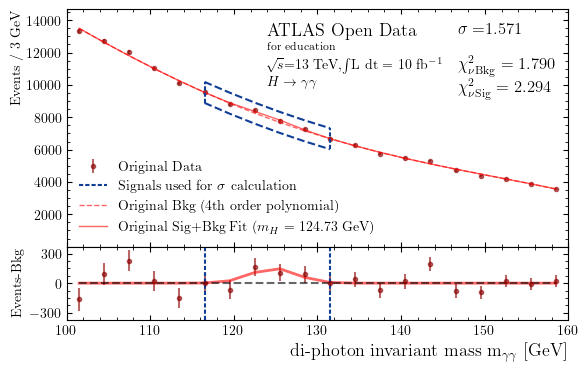

151267
21 20


: 

In [ ]:
plot_both_data(orig_masses)

In [363]:
V1 - 12,
V2 = 13,
V3 - 14,
V4 - 21

NameError: name 'V1' is not defined

In [328]:
12+13+14+21

60

In [329]:
(1+2+3+4)*6

60

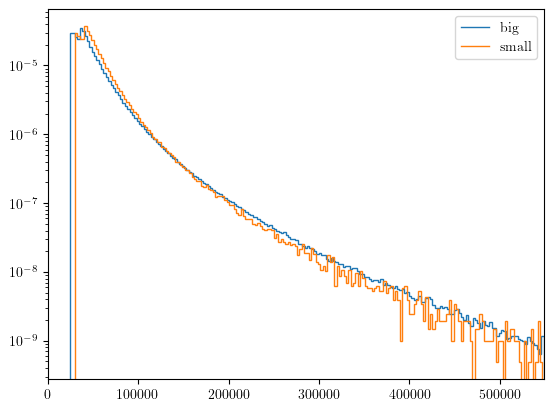

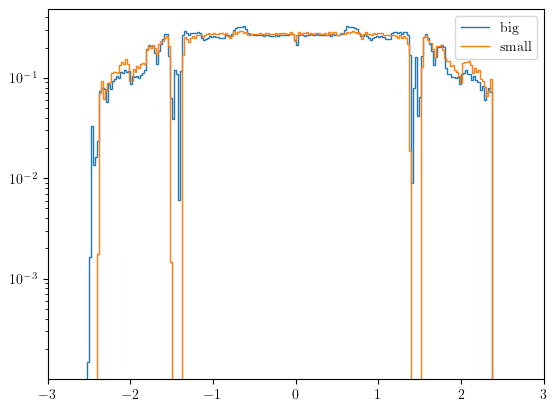

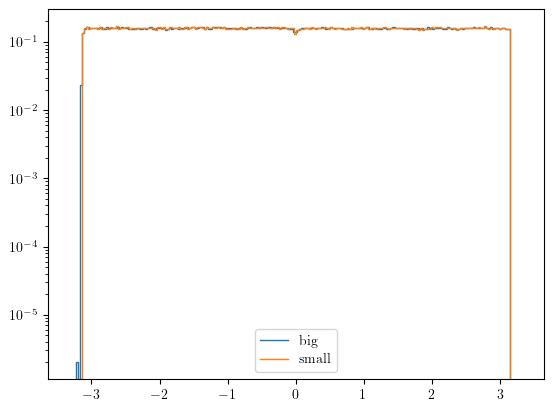

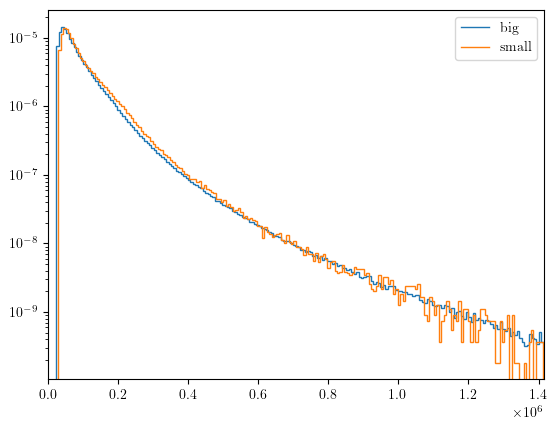

In [401]:
with (np.load("workspaces/higgs/data/V4_precut_original.npz") as big,
      np.load("workspaces/higgs/data/V5_precut_original.npz") as small):
    for i in range(0,8,2):
        fig, ax = plt.subplots()
        n_big, bins_big = np.histogram(big["data"][:,i:i+2], bins=200, density=True)
        n_small, bins_small = np.histogram(small["data"][:,i:i+2], bins=200, density=True)

        percentiles = [np.percentile(big["data"][:,i:i+2], 0.01), np.percentile(big["data"][:,i:i+2], 99.99)]
        if np.any(bins_small < 0):
            if np.any(bins_small > 3):
                lims = [-np.pi-0.5, np.pi+0.5]
            else:
                lims = [-3, 3]
        else:
            lims = [0, percentiles[1]]
        big_cut = np.where((big["data"][:,i] > lims[0]) & (big["data"][:,i+1] > lims[0]) & (big["data"][:,i] < lims[1]) & (big["data"][:,i+1] < lims[1]))[0]
        small_cut = np.where((small["data"][:,i] > lims[0]) & (small["data"][:,i+1] > lims[0]) & (small["data"][:,i] < lims[1]) & (small["data"][:,i+1] < lims[1]))[0]
        
        big_cut = big["data"][:,i:i+2][big_cut]
        small_cut = small["data"][:,i:i+2][small_cut]

        n_big, bins_big = np.histogram(big_cut, bins=200, density=True)
        n_small, bins_small = np.histogram(small_cut, bins=200, density=True)

        ax.stairs(n_big, bins_big, label="big")
        ax.stairs(n_small, bins_small, label="small")
        ax.set_xlim(lims)
        ax.set_yscale("log")

        ax.legend()
        plt.show()
        

In [4]:
import numpy as np
np.array([7.62/5.34, 3.544/4.976, 4.541/5.039, 5.924/4.071])*100

array([142.69662921,  71.22186495,  90.11708672, 145.51707197])